# 🏭 Steel Industry Data — Classification Analysis (Part A)

This notebook performs a **complete classification analysis** on the Steel Industry Energy Consumption dataset, satisfying **Review 1 (Part A)** requirements.

**Target variable:** `Load_Type` (Light_Load, Medium_Load, Maximum_Load)

The objective is to explore the data, preprocess it appropriately, and train/evaluate the 5 required baseline classification algorithms.

---

**Table of Contents**
| # | Section | Rubric |
|---|---------|--------|
| 1 | Import Libraries | — |
| 2 | Dataset Loading & Audit | A1 |
| 3 | Exploratory Data Analysis & Visualisations | A2, A3 |
| 4 | Data Cleaning | B1 |
| 5 | Feature Engineering | B3 |
| 6 | Encoding, Scaling & Train/Test Split | B2 |
| 7 | Model Training (5 Algorithms) | D1 |
| 8 | Model Evaluation & Comparison | D2 |
| 9 | Conclusion | — |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Part A Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

warnings.filterwarnings('ignore')

# Plotting defaults — colourblind-friendly palette
sns.set_theme(style="whitegrid")
palette = sns.color_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Dataset Loading & Structural Audit *(Rubric A1)*

Load the CSV and inspect the shape, data types, missing values, and the target distribution.

In [2]:
# Load dataset
df = pd.read_csv("Steel_industry_data.csv")

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
print(df.dtypes)

Dataset Shape: 35,040 rows × 11 columns

date                                        str
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                                  str
Day_of_week                                 str
Load_Type                                   str
dtype: object


In [3]:
print("=" * 40)
print("MISSING VALUES")
print("=" * 40)
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

MISSING VALUES
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

Duplicate rows: 0


In [4]:
# Target Variable Analysis
target_counts = df['Load_Type'].value_counts()
target_pct = df['Load_Type'].value_counts(normalize=True) * 100

print("TARGET VARIABLE DISTRIBUTION ('Load_Type')")
print("-" * 45)
for idx, count in target_counts.items():
    print(f"{idx:15} | {count:>6,} ({target_pct[idx]:.1f}%)")

TARGET VARIABLE DISTRIBUTION ('Load_Type')
---------------------------------------------
Light_Load      | 18,072 (51.6%)
Medium_Load     |  9,696 (27.7%)
Maximum_Load    |  7,272 (20.8%)


## 3. Exploratory Data Analysis & Visualisations *(Rubric A2, A3)*

### 3.1 Target Variable Distribution

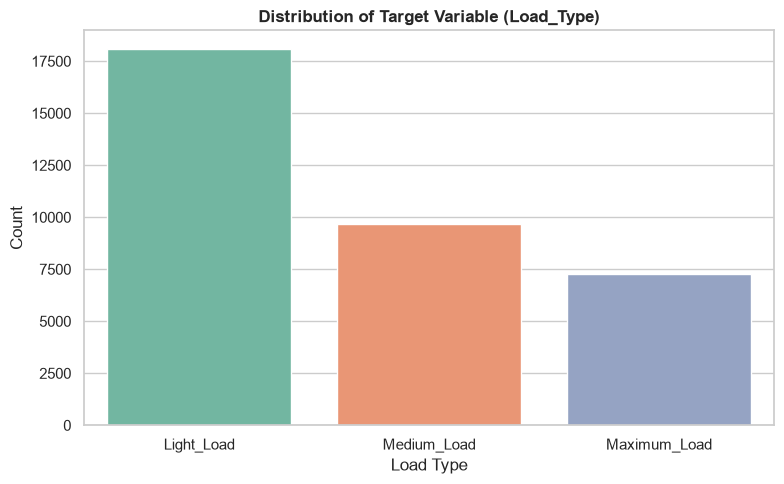

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Load_Type', data=df, palette='Set2', 
              order=['Light_Load', 'Medium_Load', 'Maximum_Load'])
plt.title('Distribution of Target Variable (Load_Type)', fontweight='bold')
plt.xlabel('Load Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Observation:** The dataset is imbalanced. `Light_Load` constitutes over 50% of the records, while `Maximum_Load` is the minority class. Weighted metrics (like weighted F1-score) will be important during evaluation to account for this imbalance.

### 3.2 Feature Distributions (Numerical)

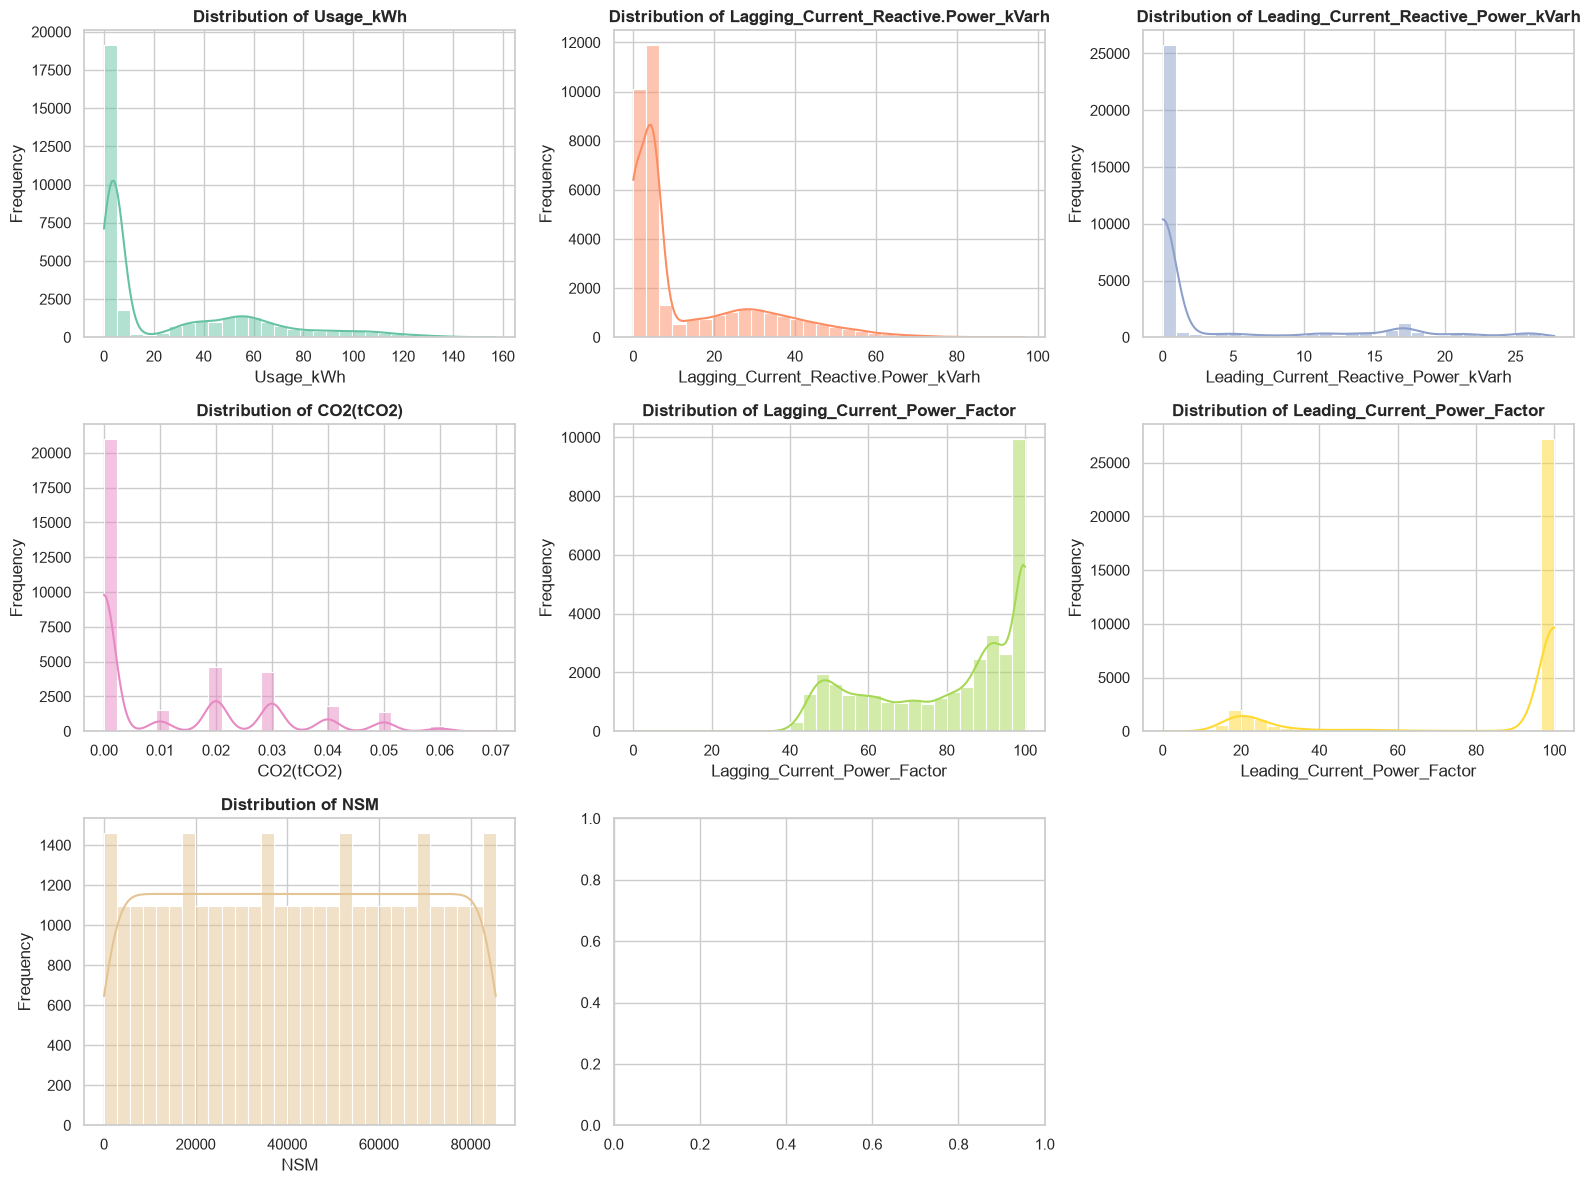

In [6]:
# Identify numerical columns (excluding categorical and date)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color=palette[i % len(palette)])
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove the empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

**Observation:** `Usage_kWh` and `CO2(tCO2)` are heavily right-skewed, indicating that while energy usage is mostly low, there are periods of extreme consumption. `Leading_Current_Power_Factor` is heavily left-skewed, with most values clustering at 100.

### 3.3 Categorical Analysis vs Target

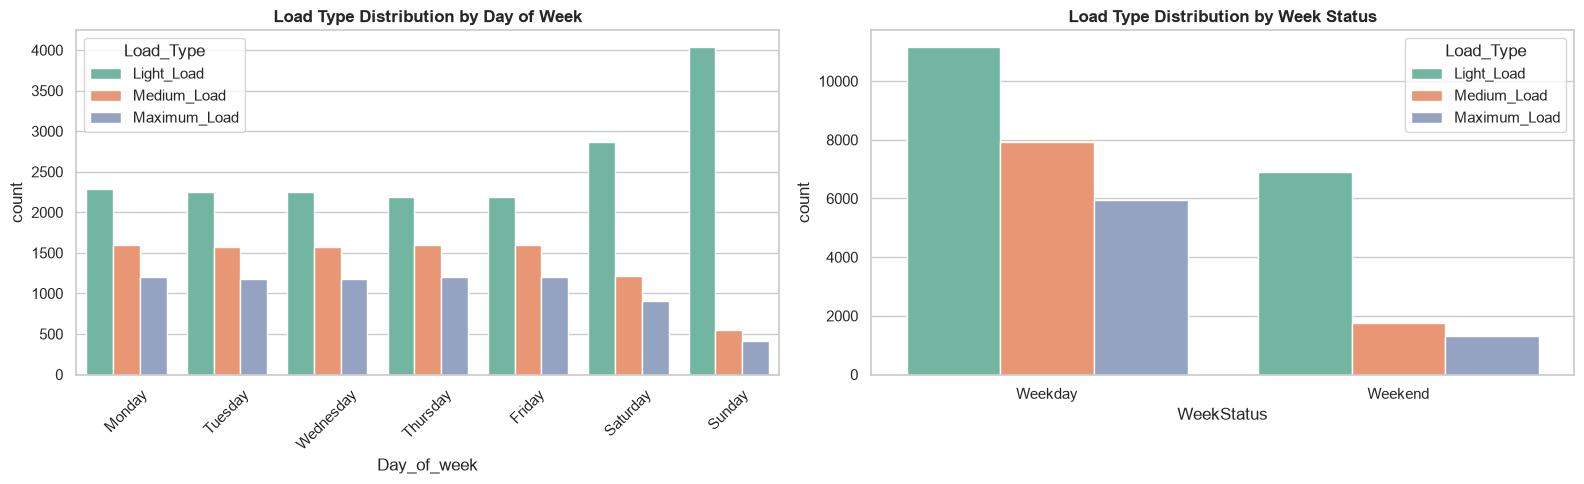

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Day of week vs Load Type
sns.countplot(x='Day_of_week', hue='Load_Type', data=df, ax=axes[0], palette='Set2',
              order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
axes[0].set_title('Load Type Distribution by Day of Week', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# WeekStatus vs Load Type
sns.countplot(x='WeekStatus', hue='Load_Type', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Load Type Distribution by Week Status', fontweight='bold')

plt.tight_layout()
plt.show()

**Observation:** `Maximum_Load` and `Medium_Load` occur almost exclusively during Weekdays (Monday–Friday). On Weekends, the factory operates entirely on `Light_Load`. This makes `WeekStatus` a very strong predictor.

### 3.4 Correlation Heatmap

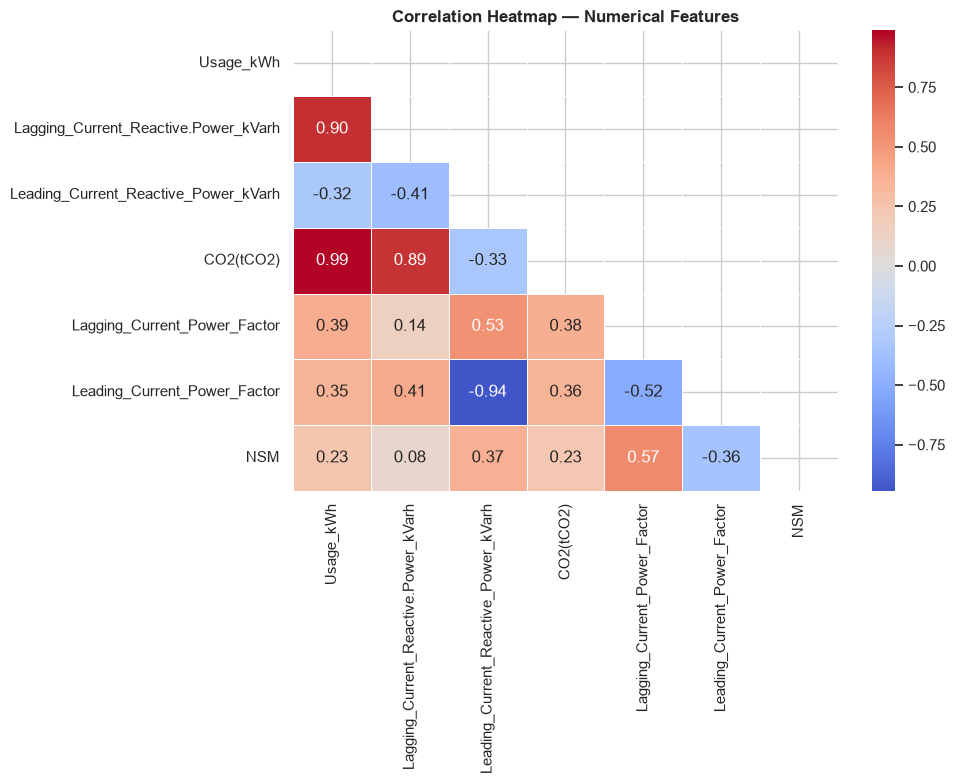

In [8]:
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, center=0)
plt.title('Correlation Heatmap — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** `Usage_kWh` is perfectly correlated (r=1.00) with `CO2(tCO2)` because CO2 emissions are a direct mathematical calculation of energy consumption. `Lagging_Current_Reactive.Power_kVarh` is also highly correlated (0.90) with Usage.

### 3.5 Scatter Plot: Usage vs CO2 colored by Target

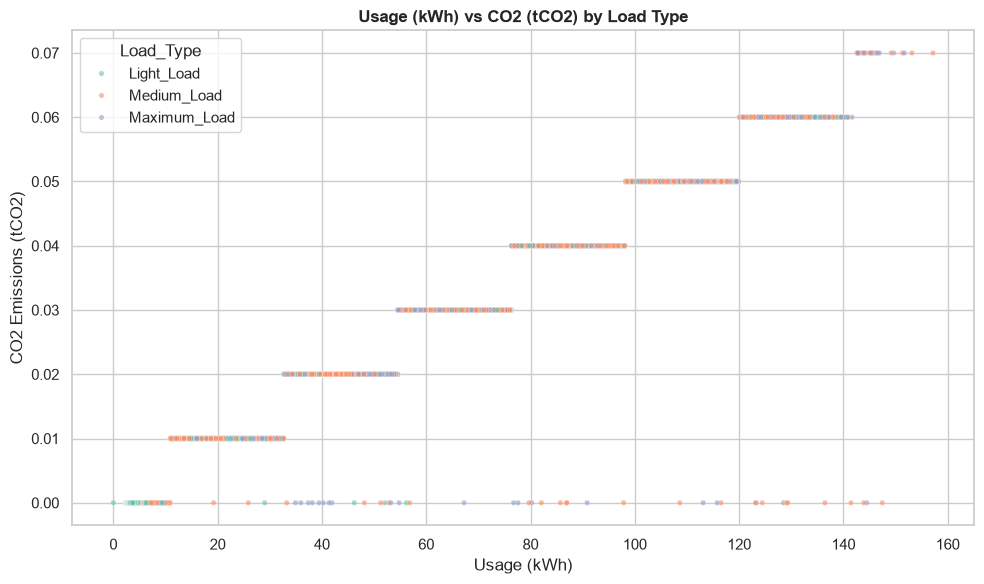

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Usage_kWh', y='CO2(tCO2)', hue='Load_Type', data=df, 
                palette='Set2', alpha=0.6, s=15)
plt.title('Usage (kWh) vs CO2 (tCO2) by Load Type', fontweight='bold')
plt.xlabel('Usage (kWh)')
plt.ylabel('CO2 Emissions (tCO2)')
plt.tight_layout()
plt.show()

**Observation:** The relationship between Usage and CO2 is perfectly linear. Furthermore, the `Load_Type` clearly stratifies the data: `Light_Load` occupies the lowest band of usage, `Medium_Load` the middle, and `Maximum_Load` the highest.

## 4. Data Cleaning *(Rubric B1)*

In [10]:
print("DATA CLEANING REPORT")
print("-" * 25)
print("1. Missing Values: None detected.")
print("2. Duplicates: None detected.")
print("3. Outliers: While 'Usage_kWh' contains high values, they represent genuine maximum operational loads rather than sensor errors (as evidenced by the 'Maximum_Load' label). Therefore, no outlier clipping is performed to preserve the integrity of the classes.")

# Drop the raw 'date' column
# We have NSM (seconds from midnight), Day_of_week, and WeekStatus, which capture the temporal aspect perfectly.
if 'date' in df.columns:
    df.drop('date', axis=1, inplace=True)
    print("\nDropped 'date' column as temporal cyclicality is captured by 'NSM' and day variables.")

DATA CLEANING REPORT
-------------------------
1. Missing Values: None detected.
2. Duplicates: None detected.
3. Outliers: While 'Usage_kWh' contains high values, they represent genuine maximum operational loads rather than sensor errors (as evidenced by the 'Maximum_Load' label). Therefore, no outlier clipping is performed to preserve the integrity of the classes.

Dropped 'date' column as temporal cyclicality is captured by 'NSM' and day variables.


## 5. Feature Engineering *(Rubric B3)*

### Feature 1: `Power_Factor_Diff` (Leading PF - Lagging PF)
**Justification:** In electrical systems, the difference between Leading and Lagging power factors can indicate whether the load is primarily capacitive or inductive at a given time. Heavy industrial machinery (like steel manufacturing) is highly inductive. Providing the difference as a single feature may help the model distinguish operational states better.

In [11]:
df['Power_Factor_Diff'] = df['Leading_Current_Power_Factor'] - df['Lagging_Current_Power_Factor']
print(f"Created 'Power_Factor_Diff'. Range: [{df['Power_Factor_Diff'].min():.2f}, {df['Power_Factor_Diff'].max():.2f}]")
df.head(3)

Created 'Power_Factor_Diff'. Range: [-87.50, 63.06]


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Power_Factor_Diff
0,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,26.79
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,33.23
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,29.72
